## analysing the changes in ENSO complexity post net zero using ACCESS net zero runs

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import os
import xarray as xr
import xcdat as xc

In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
import pandas as pd

In [4]:
import netCDF4
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3-25.09/share/proj failed


In [5]:
import cmocean
from scipy import stats

In [6]:
mpl.rcParams['font.family'] = 'Droid Sans'
mpl.rcParams['font.size'] = 14
# Edit axes parameters
mpl.rcParams['axes.linewidth'] = 0.8
# Tick properties
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.direction'] = 'out'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.direction'] = 'out'

In [7]:
def plot_decorator():
    ax = plt.gca()
    
    # Minor ticks
    # ax.minorticks_on()
    # plt.tick_params(which='minor', axis='x', bottom=False)
    
    # Grid (light, behind data)
    ax.grid(color='gray', lw=0.4, alpha=0.1)
    
    # Remove top/right spines (Nature style)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Tight layout
    # plt.tight_layout()

In [8]:
from matplotlib.colors import BoundaryNorm as BM
# from matplotlib.colors import LogNorm as LM
import matplotlib.patches as mpatches

In [9]:
def plot_background(ax, draw_labels=False):
    ax.add_feature(cfeature.COASTLINE, alpha=0.9, lw=1.1)
    # ax.set_global()
    # ax.add_feature(cfeature.LAND, color='lightgray')
    # ax.add_feature(cfeature.OCEAN, color='lightgray')
    gl = ax.gridlines(draw_labels=draw_labels,
                      linewidth=1, color='gray', alpha=0.01, linestyle='--')
    gl.top_labels = False
    # gl.left_labels = False
    # gl.bottom_labels = False
    gl.right_labels = False
    gl.xlines = False
    # gl.xlocator = mticker.FixedLocator([-180, -45, 0, 45, 180])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'color': 'k'}
    gl.ylabel_style = {'size': 10, 'color': 'k'}
    return ax


def plot_maps(x, y, z, titles, labels, cmap, levels, pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='gray', 
            nrows=1, ncols=3, figsize=(12,4), land_mask_list = [0], add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160), 
            cbar_kwargs=dict(orientation='vertical', label='Precip', aspect=40, shrink=0.7, pad=0.05), draw_labels=False, draw_colorbar=True, auto_aspect=False):

    fig, axarr = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, constrained_layout=False, subplot_kw={'projection':proj})
    
    axlist = axarr.flatten()
    
    for ax in axlist:
        if draw_labels:
            plot_background(ax, draw_labels)
        else:
            plot_background(ax)
        if auto_aspect:
            ax.set_aspect('auto')
        else:
            continue
    
    for i in range(len(z)):
        axlist[i].contourf(x, y, z[i], cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
        if draw_winds:
            wind_separation = 5
            q = axlist[i].quiver(x[::wind_separation, ::wind_separation], y[::wind_separation, ::wind_separation], u_wnd[i][::wind_separation, ::wind_separation], v_wnd[i][::wind_separation, ::wind_separation], scale=wind_scale, color='k', pivot='middle', transform=ccrs.PlateCarree())
            qk = ax.quiverkey(q, X=0.85, Y=0.9, U=1.0, label='1 m/s', labelpos='E', coordinates='axes')
            qk.text.set_bbox(dict(facecolor='white', edgecolor='k'))#, boxstyle='round,pad=0.3'))
        if draw_contour:
            axlist[i].contour(x, y, contour_data[i], cmap = None, levels=contour_levels, colors=contour_colors, transform = ccrs.PlateCarree(central_longitude=0), alpha=0.5)
        if i in land_mask_list:
            axlist[i].add_feature(cfeature.LAND, color = 'k', zorder=1)
        if pval != []:
            if hatch_type == 'insig':
                pval_plot = np.ma.masked_less_equal(pval[i], 0.05)
                axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='...', transform = ccrs.PlateCarree(central_longitude=0))
            elif hatch_type == 'sig':
                pval_plot = np.ma.masked_greater(pval[i], 0.05)
                axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='...', transform = ccrs.PlateCarree(central_longitude=0))
        axlist[i].set_title(titles[i], fontdict={'fontsize':14})
        axlist[i].text(0.1, 1.05, labels[i], size=16, fontweight='bold', transform=axlist[i].transAxes)
        if add_patch:
            # axlist[i].add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
            #                                 facecolor='none', edgecolor='k',
            #                                 transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
            #                                 facecolor='none', edgecolor='k',
            #                                 transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[140, 60], width=150, height=20,
            #                                             facecolor='none', edgecolor='tab:green', lw=1.5,
            #                                             transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[140, -80], width=150, height=20,
            #                                             facecolor='none', edgecolor='tab:green', lw=1.5,
            #                                             transform=ccrs.PlateCarree()))
        if add_patch_extra:
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, 20], width=60, height=20,
                                                        facecolor='none', edgecolor='k', lw=1.5,
                                                        transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[210, -40], width=60, height=30,
                                                        facecolor='none', edgecolor='k', lw=1.5,
                                                        transform=ccrs.PlateCarree()))
                    
    if draw_colorbar:
        norm = BM(levels, 256, extend='both')
        fig.colorbar(mpl.cm.ScalarMappable(norm = norm, cmap=cmap), ax = axlist, \
                    orientation = cbar_kwargs['orientation'], shrink=cbar_kwargs['shrink'], aspect = cbar_kwargs['aspect'], pad = cbar_kwargs['pad'], label = cbar_kwargs['label'], ticks=levels[::2])



def plot_single_map(x, y, z, title, label, cmap, levels, pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='gray', 
                figsize=(12,4), land_mask_list = False, add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160), 
                cbar_kwargs=dict(orientation='vertical', label='Precip', aspect=40, shrink=0.7, pad=0.05), draw_labels=False, draw_colorbar=True, auto_aspect=False):

    ax = plt.axes(projection=proj)
    if draw_labels:
        plot_background(ax, draw_labels)
    else:
        plot_background(ax)
    if auto_aspect:
        ax.set_aspect('auto')
    
    cf=ax.contourf(x, y, z, cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
    if draw_winds:
        wind_separation = 5
        q = ax.quiver(x[::wind_separation, ::wind_separation], y[::wind_separation, ::wind_separation], u_wnd.to_numpy()[::wind_separation, ::wind_separation], v_wnd.to_numpy()[::wind_separation, ::wind_separation], scale=wind_scale, \
        color='k', transform=ccrs.PlateCarree())
        qk = ax.quiverkey(q, X=0.85, Y=0.9, U=1.0, label='1 m/s', labelpos='E', coordinates='axes')
        qk.text.set_bbox(dict(facecolor='white', edgecolor='k'))#, boxstyle='round,pad=0.3'))
    if draw_contour:
        ax.contour(x, y, contour_data, cmap = None, levels=contour_levels, colors=contour_colors, transform = ccrs.PlateCarree(central_longitude=0), alpha=0.5)
    if land_mask_list:
        ax.add_feature(cfeature.LAND, color = 'k', zorder=1)
    if pval != []:
        if hatch_type == 'insig':
            pval_plot = np.ma.masked_less_equal(pval, 0.05)
            ax.pcolor(x, y, pval_plot, alpha = 0., hatch='...', transform = ccrs.PlateCarree(central_longitude=0))
        elif hatch_type == 'sig':
            pval_plot = np.ma.masked_greater(pval, 0.05)
            ax.pcolor(x, y, pval_plot, alpha = 0., hatch='...', transform = ccrs.PlateCarree(central_longitude=0))
    ax.set_title(title, fontdict={'fontsize':14})
    ax.text(0.1, 1.05, label, size=16, fontweight='bold', transform=ax.transAxes)
    if add_patch:
        ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                        facecolor='none', edgecolor='k',
                                        transform=ccrs.PlateCarree()))
        ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                        facecolor='none', edgecolor='k',
                                        transform=ccrs.PlateCarree()))
    
    if add_patch_extra:
        ax.add_patch(mpatches.Rectangle(xy=[190, 20], width=60, height=20,
                                                    facecolor='none', edgecolor='k', lw=1.5,
                                                    transform=ccrs.PlateCarree()))
        ax.add_patch(mpatches.Rectangle(xy=[210, -40], width=60, height=30,
                                                    facecolor='none', edgecolor='k', lw=1.5,
                                                    transform=ccrs.PlateCarree()))
                    
    if draw_colorbar:
        norm = BM(levels, 256, extend='both')
        plt.colorbar(mpl.cm.ScalarMappable(norm = norm, cmap=cmap), ax = ax, \
                    orientation = cbar_kwargs['orientation'], shrink=cbar_kwargs['shrink'], aspect = cbar_kwargs['aspect'], pad = cbar_kwargs['pad'], label = cbar_kwargs['label'], ticks=levels[::2])

In [10]:
def plot_maps_no_proj(x, y, z, titles, labels, cmap, levels, pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='gray', 
            nrows=1, ncols=3, figsize=(12,4), land_mask_list = [0], add_patch=False, add_patch_extra=False, hatch_type = 'insig', 
            cbar_kwargs=dict(orientation='vertical', label='Precip', aspect=40, shrink=0.7, pad=0.05), draw_colorbar=True, auto_aspect=False, draw_clabel=False):

    fig, axarr = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, constrained_layout=False, sharex=True, sharey=True)
    
    axlist = axarr.flatten()
    
    for ax in axlist:
        if auto_aspect:
            ax.set_aspect('auto')
        else:
            continue
    
    for i in range(len(z)):
        axlist[i].contourf(x, y, z[i], cmap = cmap, levels=levels, extend='both')
        if draw_winds:
            wind_separation = 5
            q = axlist[i].quiver(x[::wind_separation, ::wind_separation], y[::wind_separation, ::wind_separation], u_wnd[i][::wind_separation, ::wind_separation], v_wnd[i][::wind_separation, ::wind_separation], scale=wind_scale, color='k', pivot='middle')
    
            qk = ax.quiverkey(q, X=0.85, Y=0.9, U=1.0, label='1 m/s', labelpos='E', coordinates='axes')
            qk.text.set_bbox(dict(facecolor='white', edgecolor='k'))#, boxstyle='round,pad=0.3'))
        if draw_contour:
            cs = axlist[i].contour(x, y, contour_data[i], cmap = None, levels=contour_levels, colors=contour_colors, alpha=0.5)
            if draw_clabel:
                axlist[i].clabel(cs, inline=True, fontsize=8)
        if i in land_mask_list:
            axlist[i].add_feature(cfeature.LAND, color = 'k', zorder=1)
        if pval != []:
            if hatch_type == 'insig':
                pval_plot = np.ma.masked_less_equal(pval[i], 0.05)
                axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='...')
            elif hatch_type == 'sig':
                pval_plot = np.ma.masked_greater(pval[i], 0.05)
                axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='...')
        axlist[i].set_title(titles[i], fontdict={'fontsize':14})
        axlist[i].text(0.1, 1.05, labels[i], size=16, fontweight='bold', transform=axlist[i].transAxes)
                    
    if draw_colorbar:
        norm = BM(levels, 256, extend='both')
        fig.colorbar(mpl.cm.ScalarMappable(norm = norm, cmap=cmap), ax = axlist, \
                    orientation = cbar_kwargs['orientation'], shrink=cbar_kwargs['shrink'], aspect = cbar_kwargs['aspect'], pad = cbar_kwargs['pad'], label = cbar_kwargs['label'], ticks=levels[::2])
    return fig, axlist

In [11]:
from functions import preproc_funcs as funcs

In [12]:
from functions import xr_lowess

In [13]:
import xesmf as xe

In [171]:
def compute_plotting_da(input_da, type='zonal', alternate=False):
    """
    example for trans - thetao_zonal_trans_anom.sel(time = slice('2030', '2060')).mean('time').thetao
    example for stable - thetao_zonal_stable_anom2030.thetao
    """
    if type == 'zonal':
        # ds_out = xe.util.cf_grid_2d(-0.75, 360, 1.5, -90, 90, 1.5)
        # input_da = input_da.expand_dims(dim = dict(i = 360))
        # input_da['j'] = np.linspace(-90, 90, len(input_da.j))
        # input_da['i'] = np.linspace(0, 360, len(input_da.i))
        # input_da = input_da.rename(dict(i='lon', j='lat'))
        # regridder = xe.Regridder(input_da, ds_out, 'bilinear', periodic=True, ignore_degenerate=True)
        # plotting_da = regridder(input_da).mean(('lon'))
        return input_da
    elif type == 'merid':
        if alternate:
            ds_out = xe.util.cf_grid_2d(-0.75, 360, 1.5, -90, 90, 1.5)
        else:
            ds_out = xe.util.cf_grid_2d(-0.75, 360, 1.5, -5, 5, 1.5)
        # input_da = input_da.expand_dims(dim = dict(j = 40))
        input_da['j'] = input_da['latitude']
        input_da['i'] = input_da['longitude']
        input_da = input_da.rename(dict(i='lon', j='lat'))
        regridder = xe.Regridder(input_da, ds_out, 'bilinear', periodic=True, ignore_degenerate=True)
        plotting_da = regridder(input_da).mean(('lat'))
    return plotting_da

In [15]:
import glob

In [16]:
def open_thetao_da_zarr(files):
    datasets = [xr.open_zarr(f, use_cftime=True) for f in files]
    combined = xr.concat([ds['thetao'] for ds in datasets], dim='model')
    return combined

In [17]:
files_trans = glob.glob('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/thetao_tropics/*.zarr')
thetao_tropics_trans_orig = open_thetao_da_zarr(files_trans)

In [18]:
thetao_tropics_trans = funcs.calc_anom(thetao_tropics_trans_orig, thetao_tropics_trans_orig.sel(model = 10).sel(time = slice('1960', '1990')))

In [19]:
thetao_tropics_stable2030 = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/thetao_tropics/access_stable_2030*.nc', concat_dim='time', combine='nested', use_cftime=True)
print('done')
thetao_tropics_stable2045 = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/thetao_tropics/access_stable_2045*.nc', concat_dim='time', combine='nested', use_cftime=True)
print('done')
thetao_tropics_stable2060 = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/thetao_tropics/access_stable_2060*.nc', concat_dim='time', combine='nested', use_cftime=True)
print('done')


done
done
done


In [20]:
from dask.diagnostics import ProgressBar

In [21]:
with ProgressBar():
    thetao_tropics_stable_anom2030 = funcs.calc_anom_annual(thetao_tropics_stable2030, thetao_tropics_trans_orig.sel(model = 10).sel(time = slice('1960', '1990'))).load()
    thetao_tropics_stable_anom2045 = funcs.calc_anom_annual(thetao_tropics_stable2045, thetao_tropics_trans_orig.sel(model = 10).sel(time = slice('1960', '1990'))).load()
    thetao_tropics_stable_anom2060 = funcs.calc_anom_annual(thetao_tropics_stable2060, thetao_tropics_trans_orig.sel(model = 10).sel(time = slice('1960', '1990'))).load()

[                                        ] | 0% Completed | 324.85 us

[########################################] | 100% Completed | 102.02 ms
[########################################] | 100% Completed | 101.49 ms
[########################################] | 100% Completed | 3.55 sms
[########################################] | 100% Completed | 102.29 ms
[########################################] | 100% Completed | 103.11 ms
[########################################] | 100% Completed | 25.00 ss
[########################################] | 100% Completed | 102.33 ms
[########################################] | 100% Completed | 102.64 ms
[########################################] | 100% Completed | 26.42 ss


In [28]:
ts_trans_orig = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/ACCESS-ESM1-5_ssp5_ts_original.nc', use_cftime=True).ts.load()
ts_trans = funcs.calc_anom(ts_trans_orig, ts_trans_orig.sel(time = slice('1960', '1990')).sel(model = 'ACCESS-ESM1-5_r10i1p1f')).load()

In [ ]:
ts_stable_orig = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/access_stable_ts.nc', use_cftime=True).ts.load()
ts_stable = funcs.calc_anom_annual(ts_stable_orig, ts_trans_orig.sel(time = slice('1960', '1990')).sel(model = 'ACCESS-ESM1-5_r10i1p1f')).load()

In [29]:
weights_model = np.cos(np.deg2rad(ts_trans.lat))
weights_model.name='weights'
weights_model

<xarray.DataArray 'weights' (lat: 120)> Size: 960B
array([0.0130896 , 0.03925982, 0.06540313, 0.09150162, 0.1175374 ,
       0.14349262, 0.1693495 , 0.19509032, 0.22069744, 0.24615329,
       0.27144045, 0.29654157, 0.32143947, 0.34611706, 0.37055744,
       0.39474386, 0.41865974, 0.44228869, 0.46561452, 0.48862124,
       0.51129309, 0.53361452, 0.55557023, 0.57714519, 0.5983246 ,
       0.61909395, 0.639439  , 0.65934582, 0.67880075, 0.69779046,
       0.71630194, 0.73432251, 0.75183981, 0.76884183, 0.78531693,
       0.80125381, 0.81664156, 0.83146961, 0.84572782, 0.85940641,
       0.87249601, 0.88498764, 0.89687274, 0.90814317, 0.91879121,
       0.92880955, 0.93819134, 0.94693013, 0.95501994, 0.96245524,
       0.96923091, 0.97534232, 0.98078528, 0.98555606, 0.98965139,
       0.99306846, 0.99580493, 0.99785892, 0.99922904, 0.99991433,
       0.99991433, 0.99922904, 0.99785892, 0.99580493, 0.99306846,
       0.98965139, 0.98555606, 0.98078528, 0.97534232, 0.96923091,
       0.96245524, 0.95501994, 0.94693013, 0.93819134, 0.92880955,
       0.91879121, 0.90814317, 0.89687274, 0.88498764, 0.87249601,
       0.85940641, 0.84572782, 0.83146961, 0.81664156, 0.80125381,
       0.78531693, 0.76884183, 0.75183981, 0.73432251, 0.71630194,
       0.69779046, 0.67880075, 0.65934582, 0.639439  , 0.61909395,
       0.5983246 , 0.57714519, 0.55557023, 0.53361452, 0.51129309,
       0.48862124, 0.46561452, 0.44228869, 0.41865974, 0.39474386,
       0.37055744, 0.34611706, 0.32143947, 0.29654157, 0.27144045,
       0.24615329, 0.22069744, 0.19509032, 0.1693495 , 0.14349262,
       0.1175374 , 0.09150162, 0.06540313, 0.03925982, 0.0130896 ])
Coordinates:
  * lat      (lat) float64 960B -89.25 -87.75 -86.25 ... 86.25 87.75 89.25
Attributes:
    bounds:         lat_bounds
    standard_name:  latitude
    units:          degrees_north

In [30]:
nino3_trans_index = funcs.detrend_rolling_window(ts_trans.sel(lat = slice(-5, 5), lon = slice(-150+360, -90+360)).weighted(weights_model).mean(('lat', 'lon')), window_size=15)
nino3_stable_index = funcs.detrend_rolling_window(ts_stable.sel(lat = slice(-5, 5), lon = slice(-150+360, -90+360)).weighted(weights_model).mean(('lat', 'lon')), window_size=15)

In [188]:
nino3_trans = ts_trans_orig.sel(lat = slice(-5, 5), lon = slice(-150+360, -90+360)).weighted(weights_model).mean(('lat', 'lon'))
nino3_trans_anom = funcs.calc_anom(nino3_trans, nino3_trans.sel(time = slice('1960', '1990'), model='ACCESS-ESM1-5_r10i1p1f'))
# nino3_north_trans = ts_trans_orig.sel(lat = slice(5, 10), lon = slice(-150+360, -90+360)).weighted(weights_model).mean(('lat', 'lon'))

nino3_stable = ts_stable_orig.sel(lat = slice(-5, 5), lon = slice(-150+360, -90+360)).weighted(weights_model).mean(('lat', 'lon'))
nino3_stable_anom = funcs.calc_anom_annual(nino3_stable, nino3_trans.sel(time = slice('1960', '1990'), model='ACCESS-ESM1-5_r10i1p1f'))
# nino3_north_stable = ts_stable_orig.sel(lat = slice(5, 10), lon = slice(-150+360, -90+360)).weighted(weights_model).mean(('lat', 'lon'))

In [172]:
def calc_z20(input_da, type='merid'):
    da = compute_plotting_da(input_da, type=type).sel(lon = slice(120, 270)).mean(('lon'))
    warm_depth = da.lev.where(da > 20)
    z20 = warm_depth.idxmax("lev")
    return z20

In [176]:
models_z20_list = ['ACCESS-ESM1-5_r27i1p1f', 'ACCESS-ESM1-5_r10i1p1f',
       'ACCESS-ESM1-5_r31i1p1f', 'ACCESS-ESM1-5_r9i1p1f',
       'ACCESS-ESM1-5_r5i1p1f', 'ACCESS-ESM1-5_r26i1p1f',
       'ACCESS-ESM1-5_r11i1p1f', 'ACCESS-ESM1-5_r8i1p1f',
       'ACCESS-ESM1-5_r30i1p1f', 'ACCESS-ESM1-5_r4i1p1f',
       'ACCESS-ESM1-5_r25i1p1f', 'ACCESS-ESM1-5_r29i1p1f',
       'ACCESS-ESM1-5_r33i1p1f', 'ACCESS-ESM1-5_r12i1p1f',
       'ACCESS-ESM1-5_r7i1p1f', 'ACCESS-ESM1-5_r24i1p1f',
       'ACCESS-ESM1-5_r28i1p1f', 'ACCESS-ESM1-5_r32i1p1f',
       'ACCESS-ESM1-5_r13i1p1f', 'ACCESS-ESM1-5_r6i1p1f',
       'ACCESS-ESM1-5_r40i1p1f', 'ACCESS-ESM1-5_r23i1p1f',
       'ACCESS-ESM1-5_r39i1p1f', 'ACCESS-ESM1-5_r1i1p1f',
       'ACCESS-ESM1-5_r18i1p1f', 'ACCESS-ESM1-5_r14i1p1f',
       'ACCESS-ESM1-5_r35i1p1f', 'ACCESS-ESM1-5_r22i1p1f',
       'ACCESS-ESM1-5_r38i1p1f', 'ACCESS-ESM1-5_r19i1p1f',
       'ACCESS-ESM1-5_r15i1p1f', 'ACCESS-ESM1-5_r34i1p1f',
       'ACCESS-ESM1-5_r21i1p1f', 'ACCESS-ESM1-5_r3i1p1f',
       'ACCESS-ESM1-5_r37i1p1f', 'ACCESS-ESM1-5_r16i1p1f',
       'ACCESS-ESM1-5_r20i1p1f', 'ACCESS-ESM1-5_r2i1p1f',
       'ACCESS-ESM1-5_r36i1p1f', 'ACCESS-ESM1-5_r17i1p1f']

In [190]:
z20_trans = calc_z20(thetao_tropics_trans_orig)
z20_trans['model']  = models_z20_list
z20_trans_anom = funcs.calc_anom(z20_trans, z20_trans.sel(time = slice('1960', '1990'), model = 'ACCESS-ESM1-5_r10i1p1f'))
z20_trans_index = funcs.detrend_rolling_window(z20_trans_anom, window_size=15)

In [193]:
nino3_trans_index = nino3_trans_index.sortby('model')
z20_trans_index = z20_trans_index.sortby('model')

In [200]:
import seaborn as sns

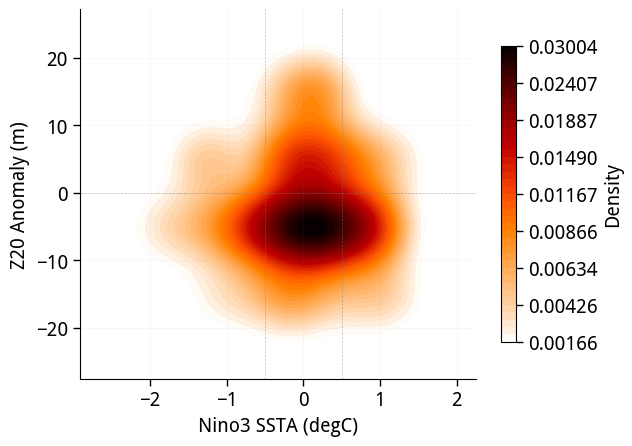

In [207]:
xval = nino3_trans_index.sel(time = slice('2070', '2100')).isel(model = 3)
yval = z20_trans_anom.sel(time = slice('2070', '2100')).isel(model=3)

sns.kdeplot(x=xval, y=yval, fill=True, cmap='gist_heat_r', cbar=True, levels=41, cbar_kws=dict(label='Density', shrink=0.8), thresh=0.05)
plt.xlabel('Nino3 SSTA (degC)')
plt.ylabel('Z20 Anomaly (m)')
plot_decorator()
plt.axhline(0.0, color='gray', lw=0.5, ls='--', alpha=0.5)
plt.axvline(-0.5, color='gray', lw=0.5, ls='--', alpha=0.5)
plt.axvline(0.5, color='gray', lw=0.5, ls='--', alpha=0.5)

In [214]:
def get_ens_mean_kde(xval, yval):
    n_models = int(len(xval.model))

    # Create a grid for KDE evaluation
    xgrid = np.linspace(float(xval.min()), float(xval.max()), 200)
    ygrid = np.linspace(float(yval.min()), float(yval.max()), 200)
    X, Y = np.meshgrid(xgrid, ygrid)
    positions = np.vstack([X.ravel(), Y.ravel()])

    # Compute KDE for each ensemble member
    densities = []
    for m in range(n_models):
        x = xval.isel(model=m).values
        y = yval.isel(model=m).values
        mask = np.isfinite(x) & np.isfinite(y)
        kde = stats.gaussian_kde(np.vstack([x[mask], y[mask]]))
        densities.append(kde(positions))

    # Ensemble mean KDE
    mean_density = np.mean(densities, axis=0)
    Z = mean_density.reshape(X.shape)
    return X, Y, Z


In [218]:
xval = nino3_trans_index.sel(time = slice('1850', '1900'))
yval = z20_trans_anom.sel(time = slice('1850', '1900'))

# sns.kdeplot(x=xval, y=yval, fill=True, cmap='gist_heat_r', cbar=True, levels=41, cbar_kws=dict(label='Density', shrink=0.8), thresh=0.05)
# plt.xlabel('Nino3 SSTA (degC)')
# plt.ylabel('Z20 Anomaly (m)')
# plot_decorator()

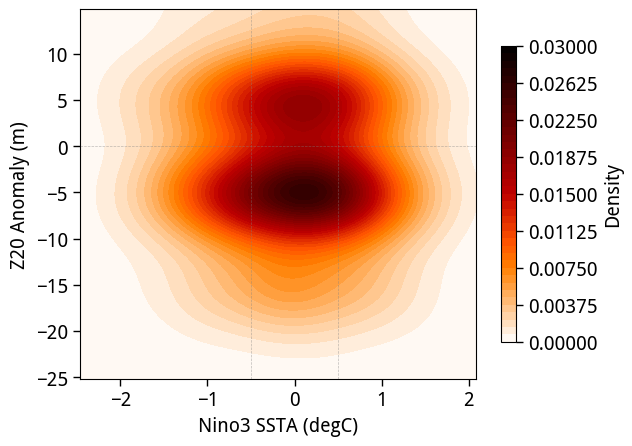

In [219]:
# Plot
# plt.figure(figsize=(7, 6))
X, Y, Z = get_ens_mean_kde(xval, yval)
contour = plt.contourf(X, Y, Z, levels=np.linspace(0, 0.03, 41), cmap="gist_heat_r")
cbar = plt.colorbar(contour, label='Density', shrink=0.8)
plt.xlabel('Nino3 SSTA (degC)')
plt.ylabel('Z20 Anomaly (m)')
# plot_decorator()
plt.axhline(0.0, color='gray', lw=0.5, ls='--', alpha=0.5)
plt.axvline(-0.5, color='gray', lw=0.5, ls='--', alpha=0.5)
plt.axvline(0.5, color='gray', lw=0.5, ls='--', alpha=0.5)

In [ ]:
z20_trans_index.sel(time = slice('1850', '1900')).isel(model=0).plot()
plt.axhline(z20_trans_index.sel(time = slice('1850', '1900')).isel(model=0).mean('time'))

In [215]:
xval = nino3_trans_index.sel(time = slice('2045', '2075'))
yval = z20_trans_anom.sel(time = slice('2045', '2075'))

# sns.kdeplot(x=xval, y=yval, fill=True, cmap='gist_heat_r', cbar=True, levels=41, cbar_kws=dict(label='Density', shrink=0.8), thresh=0.05)
# plt.xlabel('Nino3 SSTA (degC)')
# plt.ylabel('Z20 Anomaly (m)')
# plot_decorator()

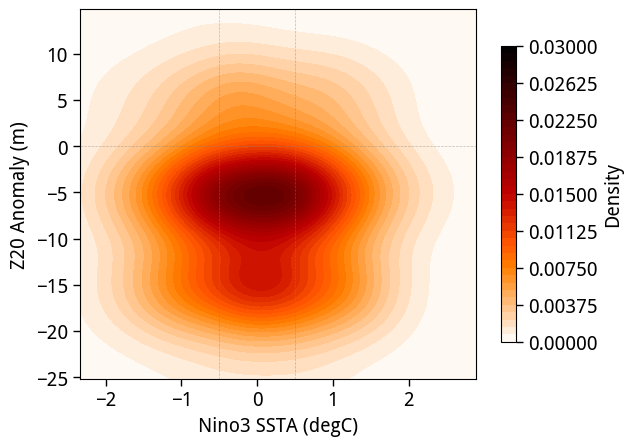

In [217]:
# Plot
# plt.figure(figsize=(7, 6))
X, Y, Z = get_ens_mean_kde(xval, yval)
contour = plt.contourf(X, Y, Z, levels=np.linspace(0, 0.03, 41), cmap="gist_heat_r")
cbar = plt.colorbar(contour, label='Density', shrink=0.8)
plt.xlabel('Nino3 SSTA (degC)')
plt.ylabel('Z20 Anomaly (m)')
# plot_decorator()
plt.axhline(0.0, color='gray', lw=0.5, ls='--', alpha=0.5)
plt.axvline(-0.5, color='gray', lw=0.5, ls='--', alpha=0.5)
plt.axvline(0.5, color='gray', lw=0.5, ls='--', alpha=0.5)

In [ ]:
xval = nino3_trans_index.sel(time = slice('2045', '2075'))
yval = z20_trans_anom.sel(time = slice('2045', '2075'))

# sns.kdeplot(x=xval, y=yval, fill=True, cmap='gist_heat_r', cbar=True, levels=41, cbar_kws=dict(label='Density', shrink=0.8), thresh=0.05)
# plt.xlabel('Nino3 SSTA (degC)')
# plt.ylabel('Z20 Anomaly (m)')
# plot_decorator()

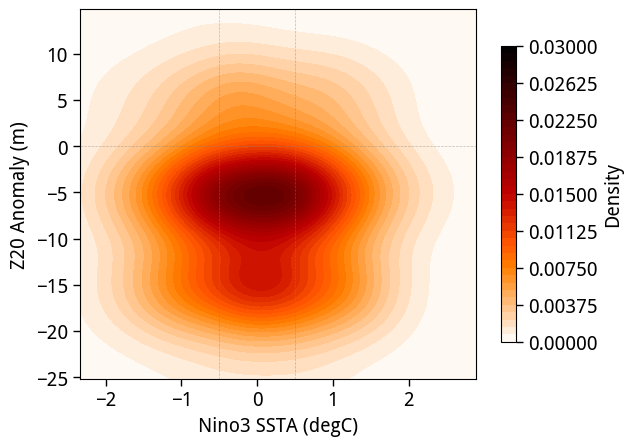

In [ ]:
# Plot
# plt.figure(figsize=(7, 6))
X, Y, Z = get_ens_mean_kde(xval, yval)
contour = plt.contourf(X, Y, Z, levels=np.linspace(0, 0.03, 41), cmap="gist_heat_r")
cbar = plt.colorbar(contour, label='Density', shrink=0.8)
plt.xlabel('Nino3 SSTA (degC)')
plt.ylabel('Z20 Anomaly (m)')
# plot_decorator()
plt.axhline(0.0, color='gray', lw=0.5, ls='--', alpha=0.5)
plt.axvline(-0.5, color='gray', lw=0.5, ls='--', alpha=0.5)
plt.axvline(0.5, color='gray', lw=0.5, ls='--', alpha=0.5)